# Segmenting customers

### The goal of this project is to segment the customers of a shopping website with several product categories.

Initially I will be using some data cleaning and exploratory data analysis techniques. Next I will perform a cohort analysis to understand the user profiles, and finally I will work on segmenting the data.

In [112]:
# Importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import nltk, warnings
import plotly.express as px
import seaborn as sns

##machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn import base

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_samples, silhouette_score 

from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA


## 1 Data cleaning

- Attributes to fix
    - Change the column names to snake-case and all lowercase
    - Remove null values in customer_id from the table, since they do not allow me to build a customer profile;
    - Look for and remove duplicate values;
    - Change the data type of invoice_date to datetime;
    - Remove from the table the negative values in the 'quantity' column;
    - Check and handle the data in the 'unit_price' column if necessary;
    - Add a column with the total spent per user (total_spent)

- Attributes to evaluate
    - Perform the cohort analysis to understand the amounts spent on the products
    - Segment the customers through RFM
    - Segment by creating categories for the products.

- Draw conclusions from the results and suggest action plans for the points observed.

In [2]:
#importing the dataset
ecommerce = pd.read_csv('dataset/ecommerce_dataset_us.csv')

In [3]:
ecommerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65535 entries, 0 to 65534
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    65535 non-null  object 
 1   StockCode    65535 non-null  object 
 2   Description  65372 non-null  object 
 3   Quantity     65535 non-null  int64  
 4   InvoiceDate  65535 non-null  object 
 5   UnitPrice    65535 non-null  float64
 6   CustomerID   41231 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 3.5+ MB


In [4]:
# Rename the columns so they follow snake-case and are all lowercase
new_column_names = ['invoice_no','stock_code','description','quantity','invoice_date','unit_price','customer_id']

ecommerce.rename(columns=dict(zip(ecommerce.columns, new_column_names)), inplace=True)

In [5]:
print(ecommerce.head())

  invoice_no stock_code                     description  quantity  \
0    C541433      23166  MEDIUM CERAMIC TOP STORAGE JAR    -74215   
1     541431      23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
2     537626     85232D   SET/3 DECOUPAGE STACKING TINS         3   
3     537626      22725  ALARM CLOCK BAKELIKE CHOCOLATE         4   
4     537626      22726      ALARM CLOCK BAKELIKE GREEN         4   

       invoice_date  unit_price  customer_id  
0  01/16/2019 10:17        1.04      12346.0  
1  01/16/2019 10:01        1.04      12346.0  
2  12/05/2018 14:57        4.95      12347.0  
3  12/05/2018 14:57        3.75      12347.0  
4  12/05/2018 14:57        3.75      12347.0  


In [6]:
# Handle the data in the customer_id column
ecommerce_clean = ecommerce[~ecommerce['customer_id'].isna()]

In [7]:
ecommerce_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41231 entries, 0 to 41230
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   invoice_no    41231 non-null  object 
 1   stock_code    41231 non-null  object 
 2   description   41231 non-null  object 
 3   quantity      41231 non-null  int64  
 4   invoice_date  41231 non-null  object 
 5   unit_price    41231 non-null  float64
 6   customer_id   41231 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 2.5+ MB


In [8]:
# Update the data format of 'customer_id' to int
ecommerce_clean['customer_id'] = ecommerce_clean['customer_id'].astype('int')

C:\Users\renan\AppData\Local\Temp\ipykernel_4032\3316102296.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean['customer_id'] = ecommerce_clean['customer_id'].astype('int')


### 1.1 Remove possible double spaces from the 'description' column

In [9]:
# Removing the double spaces

ecommerce_clean['description'] = ecommerce_clean['description'].str.replace(r'\s+', ' ', regex=True)

C:\Users\renan\AppData\Local\Temp\ipykernel_4032\1543203026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean['description'] = ecommerce_clean['description'].str.replace(r'\s+', ' ', regex=True)


### 1.2 Remove duplicate data

In [10]:
# Get the total number of duplicate values
print(ecommerce_clean.duplicated().value_counts())

False    40579
True       652
Name: count, dtype: int64


In [11]:
# Removing duplicates
ecommerce_clean = ecommerce_clean.drop_duplicates()

In [12]:
# Checking whether the duplicates were removed
print(ecommerce_clean.duplicated().value_counts())

False    40579
Name: count, dtype: int64


- Removing the duplicate data worked.

### 1.3 Handling the data in the 'quantity' column

In [13]:
# Filtering the data to remove negative 'quantity' values by selecting only values greater than or equal to 1

ecommerce_clean = ecommerce_clean[ecommerce_clean['quantity']>= 1]

In [14]:
ecommerce_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39531 entries, 1 to 41230
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   invoice_no    39531 non-null  object 
 1   stock_code    39531 non-null  object 
 2   description   39531 non-null  object 
 3   quantity      39531 non-null  int64  
 4   invoice_date  39531 non-null  object 
 5   unit_price    39531 non-null  float64
 6   customer_id   39531 non-null  int32  
dtypes: float64(1), int32(1), int64(1), object(4)
memory usage: 2.3+ MB


In [15]:
# Change the data type of 'invoice_date' to datetime

ecommerce_clean['invoice_date'] = pd.to_datetime(ecommerce_clean['invoice_date'])

In [16]:
print(ecommerce_clean.head(3))

  invoice_no stock_code                     description  quantity  \
1     541431      23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
2     537626     85232D   SET/3 DECOUPAGE STACKING TINS         3   
3     537626      22725  ALARM CLOCK BAKELIKE CHOCOLATE         4   

         invoice_date  unit_price  customer_id  
1 2019-01-16 10:01:00        1.04        12346  
2 2018-12-05 14:57:00        4.95        12347  
3 2018-12-05 14:57:00        3.75        12347  


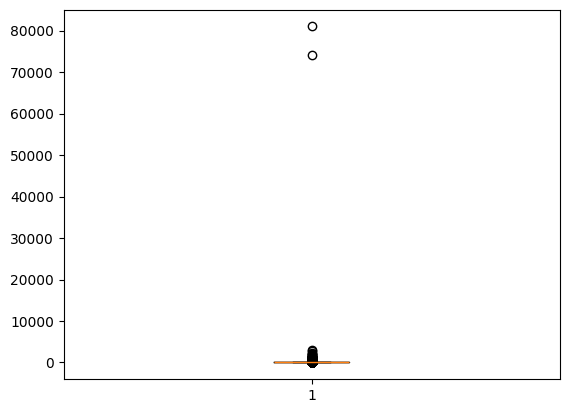

In [17]:
# Check the quantity data, since there seem to be some extreme values

quantity_values = ecommerce_clean['quantity']

plt.boxplot(quantity_values)
plt.show()

In [18]:
# Filter the data to remove 'quantity' values above 10000

ecommerce_clean = ecommerce_clean[ecommerce_clean['quantity']<=10000]

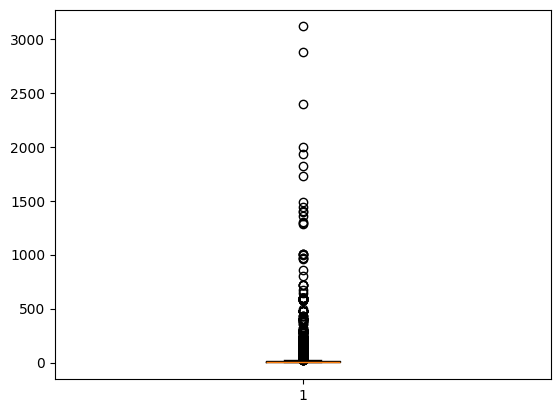

In [19]:
# Check the quantity data after removal

quantity_values_2 = ecommerce_clean['quantity']

plt.boxplot(quantity_values_2)
plt.show()

In [20]:
''' I believe there is something wrong with this data with values above 1000 items in the same order
    I am thinking of grouping by user and order and looking at the maximum number of products ordered'''

group_user_orders = ecommerce_clean.groupby(['customer_id','description','unit_price'])['quantity'].max().sort_values(ascending=False)
print(group_user_orders.head(20))

customer_id  description                         unit_price
15749        FAIRY CAKE FLANNEL ASSORTED COLOUR  2.10          3114
16754        WORLD WAR 2 GLIDERS ASSTD DESIGNS   0.18          2880
16029        GROW A FLYTRAP OR SUNFLOWER IN TIN  0.94          2400
15749        GIN + TONIC DIET METAL SIGN         1.85          2000
             WHITE HANGING HEART T-LIGHT HOLDER  2.55          1930
15299        ASSORTED COLOUR T-LIGHT HOLDER      0.55          1824
12875        ASSORTED LAQUERED INCENSE HOLDERS   0.17          1728
12755        ROUND SNACK BOXES SET OF 4 FRUITS   2.55          1488
14156        ASSORTED INCENSE PACK               0.16          1440
16754        RED HARMONICA IN BOX                1.06          1400
17857        MINI PAINT SET VINTAGE              0.55          1394
17450        HEART OF WICKER SMALL               1.93          1356
15749        TEA TIME TEA TOWELS                 2.55          1300
17306        PACK OF 12 LONDON TISSUES           0.25   

- With this information I can see that some of the order data is probably wrong, so I will filter the dataframe for quantities above and below 300 orders and look at the result in the data

In [21]:
# Filtering the quantities with a limit of 300

above_300 = ecommerce_clean[ecommerce_clean['quantity'] >= 300]
below_300 = ecommerce_clean[ecommerce_clean['quantity'] < 300]

In [22]:
above_300.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 479 to 40054
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    89 non-null     object        
 1   stock_code    89 non-null     object        
 2   description   89 non-null     object        
 3   quantity      89 non-null     int64         
 4   invoice_date  89 non-null     datetime64[ns]
 5   unit_price    89 non-null     float64       
 6   customer_id   89 non-null     int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 5.2+ KB


In [23]:
below_300.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39440 entries, 2 to 41230
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    39440 non-null  object        
 1   stock_code    39440 non-null  object        
 2   description   39440 non-null  object        
 3   quantity      39440 non-null  int64         
 4   invoice_date  39440 non-null  datetime64[ns]
 5   unit_price    39440 non-null  float64       
 6   customer_id   39440 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 2.3+ MB


In [24]:
# Check the list with the maximum values up to 300 orders

group_below_300 = below_300.groupby(['customer_id','description','unit_price'])['quantity'].max().sort_values(ascending=False)
print(group_below_300.head(20))

customer_id  description                         unit_price
15311        DECORATIVE CATS BATHROOM BOTTLE     0.42          288
17511        DISCO BALL CHRISTMAS DECORATION     0.10          288
18092        MOROCCAN TEA GLASS                  0.65          288
14646        5 HOOK HANGER RED MAGIC TOADSTOOL   1.45          288
17404        TEA BAG PLATE RED RETROSPOT         0.85          288
16422        SET/10 RED POLKADOT PARTY CANDLES   1.06          288
14156        SET/5 RED SPOTTY LID GLASS BOWLS    2.55          288
17511        FELT FARM ANIMAL WHITE BUNNY        0.19          288
14646        ASSORTED EASTER DECORATIONS BELLS   1.06          288
             PLASTERS IN TIN WOODLAND ANIMALS    1.45          288
16191        HAND WARMER BABUSHKA DESIGN         0.85          288
16210        POTTERING MUG                       0.42          288
16684        FANCY FONT BIRTHDAY CARD            0.36          288
14646        SET/10 BLUE POLKADOT PARTY CANDLES  1.06          288
16

- Looking at the products I can say that even after filtering for orders with a quantity below 300, we still have products with values that do not look appropriate for these types of products.
- It is necessary to process this data again and apply another filter; in this case I will work with 100 items

In [25]:
# Filtering the quantities with a limit of 100

above_100 = ecommerce_clean[ecommerce_clean['quantity'] >= 100]
below_100 = ecommerce_clean[ecommerce_clean['quantity'] < 100]

In [26]:
above_100.info()

<class 'pandas.core.frame.DataFrame'>
Index: 621 entries, 45 to 40644
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    621 non-null    object        
 1   stock_code    621 non-null    object        
 2   description   621 non-null    object        
 3   quantity      621 non-null    int64         
 4   invoice_date  621 non-null    datetime64[ns]
 5   unit_price    621 non-null    float64       
 6   customer_id   621 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 36.4+ KB


In [27]:
below_100.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38908 entries, 2 to 41230
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    38908 non-null  object        
 1   stock_code    38908 non-null  object        
 2   description   38908 non-null  object        
 3   quantity      38908 non-null  int64         
 4   invoice_date  38908 non-null  datetime64[ns]
 5   unit_price    38908 non-null  float64       
 6   customer_id   38908 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 2.2+ MB


In [28]:
# Check the list with the maximum values up to 100 orders

group_below_100 = below_100.groupby(['customer_id','description','unit_price'])['quantity'].max().sort_values(ascending=False)
print(group_below_100.head(20))

customer_id  description                          unit_price
12415        PINK POLKADOT PLATE                  1.45          96
12370        HEART DECORATION PAINTED ZINC        0.65          96
14646        PLASTERS IN TIN VINTAGE PAISLEY      1.45          96
13089        HEART IVORY TRELLIS SMALL            1.25          96
14646        PLASTERS IN TIN STRONGMAN            1.45          96
14258        SET/6 RED SPOTTY PAPER PLATES        0.64          96
14646        BLUE POLKADOT CUP                    0.72          96
14258        SET/20 RED RETROSPOT PAPER NAPKINS   0.64          96
15061        MAGIC DRAWING SLATE SPACEBOY         0.36          96
17511        6 RIBBONS SHIMMERING PINKS           0.42          96
14062        HAND WARMER BABUSHKA DESIGN          0.85          96
17511        BAG 125g SWIRLY MARBLES              0.36          96
15330        FEATHER PEN LIGHT PINK               0.39          96
14646        BLUE STRIPE CERAMIC DRAWER KNOB      1.06          96
1

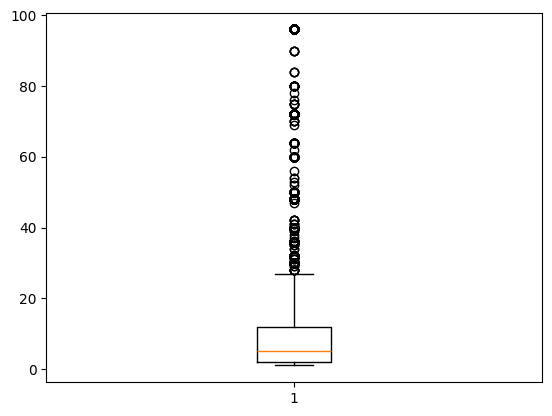

In [29]:
# Plot a histogram of quantities below 100

quant_below_100 = below_100['quantity']

plt.boxplot(quant_below_100)
plt.show()

- Based on this new boxplot it is possible to see the distribution of the data, where the upper limit is close to 20.
    - The next step is to calculate this limit, filter the data again and see whether it is worth keeping the new filter or using the data with quantities below 100

In [30]:
''' Note to self: I could have done this right after making the first boxplot instead of guessing values'''

# Calculate the upper limit of the boxplot

# Calculate the third quartile
q3 = below_100['quantity'].quantile(0.75)

# Calculate the first quartile
q1 = below_100['quantity'].quantile(0.25)

# Calculate the interquartile range (IQR)
iqr = q3-q1

# Calculate the upper limit
upper_limit = q3 + 1.5 * iqr

print("The upper limit is: ", upper_limit)

O limite superior é:  27.0


- Since I found that the upper limit is 27, I will filter the data for 'quantity' up to 27 and then study the data

In [31]:
# Filtering the data for quantity up to 27
below_27 = ecommerce_clean[ecommerce_clean['quantity'] <= 27]

In [32]:
below_27.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36844 entries, 2 to 41230
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    36844 non-null  object        
 1   stock_code    36844 non-null  object        
 2   description   36844 non-null  object        
 3   quantity      36844 non-null  int64         
 4   invoice_date  36844 non-null  datetime64[ns]
 5   unit_price    36844 non-null  float64       
 6   customer_id   36844 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(1), object(3)
memory usage: 2.1+ MB


In [33]:
# Checking the total number of unique users after filtering

unique_users_27 = below_27['customer_id'].nunique()

print(unique_users_27)

1680


- Based on the results obtained we have 1680 unique users in the new filtered dataframe

### 1.4 Studying the 'unit_price' column

- First of all, I will rename the 'below_27' dataframe to 'ecommerce_clean_27' so I understand where this data came from, since it was cleaned once and filtered.

In [34]:
# Renaming the Dataframe for further work

ecommerce_clean_27 = below_27

In [35]:
# Check the list with the maximum values up to 100 orders

group_unit_price = ecommerce_clean_27.groupby(['description','quantity'])['unit_price'].max().sort_values(ascending=False)
print(group_unit_price.head(20))

description                        quantity
VINTAGE RED KITCHEN CABINET        1           295.00
LOVE SEAT ANTIQUE WHITE METAL      2           175.00
RUSTIC SEVENTEEN DRAWER SIDEBOARD  1           165.00
REGENCY MIRROR WITH SHUTTERS       1           165.00
CARRIAGE                           1           150.00
RUSTIC SEVENTEEN DRAWER SIDEBOARD  2           145.00
CHEST NATURAL WOOD 20 DRAWERS      1           125.00
VINTAGE RED KITCHEN CABINET        2           125.00
VINTAGE BLUE KITCHEN CABINET       1           125.00
                                   2           125.00
CHEST NATURAL WOOD 20 DRAWERS      4           110.00
VINTAGE POST OFFICE CABINET        1            79.95
SCHOOL DESK AND CHAIR              1            65.00
                                   2            65.00
VINTAGE POST OFFICE CABINET        10           52.77
HALL CABINET WITH 3 DRAWERS        1            49.95
PINK PAINTED KASHMIRI CHAIR        4            42.95
POSTAGE                            2  

- Looking at the item prices, they seem consistent with the items in question.

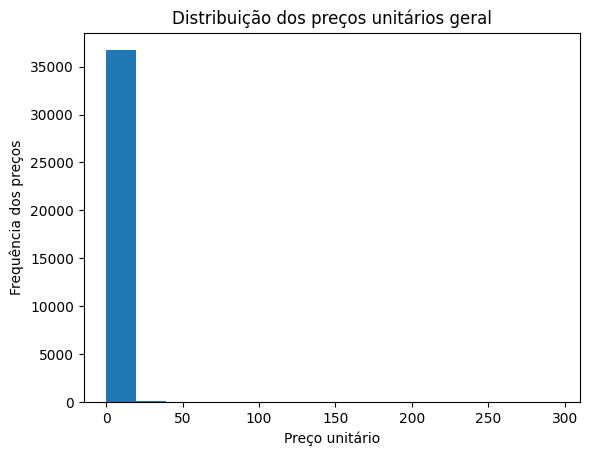

In [36]:
# Histogram of the price distribution
plt.hist(ecommerce_clean_27['unit_price'], bins=15)
plt.ylabel('Price frequency')
plt.xlabel('Unit price')
plt.title('Overall unit price distribution')
plt.show()

- The histogram shows us that the vast majority of the products' unit prices fall between zero and 25.

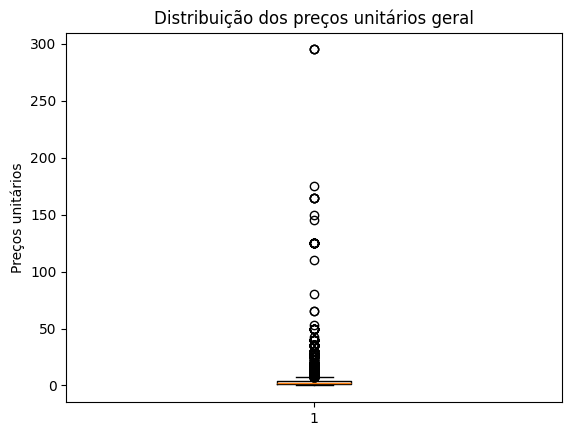

In [37]:
# Boxplot of the price distribution
plt.boxplot(ecommerce_clean_27['unit_price'])
plt.ylabel('Unit prices')
plt.title('Overall unit price distribution')
plt.show()

- With the boxplot of unit prices we can see that there are several products with outlier values, justified by the type of product itself.

In [38]:
# Calculate the upper limit of the boxplot

# Calculate the third quartile
q3 = ecommerce_clean_27['unit_price'].quantile(0.75)

# Calculate the first quartile
q1 = ecommerce_clean_27['unit_price'].quantile(0.25)

# Calculate the interquartile range (IQR)
iqr = q3-q1

# Calculate the upper limit
upper_limit = q3 + 1.5 * iqr

print("The upper price limit is: ", upper_limit)

O limite superior de preço é:  7.5


- From the boxplot we can see that the upper unit price limit is 7.5, and since the store sells much more expensive products that sell less frequently, this explains the outliers.

### 1.5 Data summary


In [39]:
#Create a table to summarize the data
pd.DataFrame([{'products': len(ecommerce_clean_27['stock_code'].value_counts()),
               'transactions':len(ecommerce_clean_27['invoice_no'].value_counts()),
               'customers':len(ecommerce_clean_27['customer_id'].value_counts()),
               }], columns=['products','transactions','customers'], index=['quantity'])

,products,transactions,customers
quantity,2543,3438,1680


- After all the data cleaning we can see that the results come from 1680 users, who bought 2543 different products, with a total of 3438 transactions carried out.

### 1.6 Cancelled orders

In [40]:
# Determine the number of products per basket
temp = ecommerce_clean_27.groupby(by=['customer_id','invoice_no'], as_index=False)['invoice_date'].count()
nb_products_per_basket = temp.rename(columns={'invoice_date':'number_of_products'})
print(nb_products_per_basket[:10].sort_values('customer_id'))

   customer_id invoice_no  number_of_products
0        12347     537626                  29
1        12347     556201                   1
2        12348     539318                   5
3        12356     541430                  22
4        12357     574740                   5
5        12359     540946                  16
6        12360     563749                   1
7        12364     573401                   1
8        12370     538826                  77
9        12370     539330                   8


In [41]:
# Determine the number of cancelled orders
nb_products_per_basket['order_canceled'] = nb_products_per_basket['invoice_no'].apply(lambda x:int('C' in x))
display(nb_products_per_basket[:5])

# Count the number of cancelled ones

n1 = nb_products_per_basket['order_canceled'].sum()
n2 = nb_products_per_basket.shape[0]
print('Number of cancelled orders: {}/{} ({:.2f}%) '.format(n1, n2, n1/n2*100))

,customer_id,invoice_no,number_of_products,order_canceled
0,12347,537626,29,0
1,12347,556201,1,0
2,12348,539318,5,0
3,12356,541430,22,0
4,12357,574740,5,0


Número de ordens canceladas: 0/3438 (0.00%) 


- In this case I can see that there are no cancelled orders within the dataset.

### 1.7 - Total spent per order

#### 1.7.1 - Creating a column with the total spent

In [42]:
ecommerce_clean_27['total_spent'] = (ecommerce_clean_27['unit_price'] * ecommerce_clean_27['quantity'])

C:\Users\renan\AppData\Local\Temp\ipykernel_4032\3784831467.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean_27['total_spent'] = (ecommerce_clean_27['unit_price'] * ecommerce_clean_27['quantity'])


#### 1.7.2 Checking whether all values are numeric

In [43]:
#Printing to see whether all the values in the total_spent column are numeric
try:
    pd.to_numeric(ecommerce_clean_27['total_spent'])
    print("The 'total_spent' column contains only numbers.")
except ValueError:
    print("The 'total_spent' column contains non-numeric values.")

A coluna 'total_spent' contém apenas números.


In [44]:
# Create a temporary table
temp = ecommerce_clean_27.groupby(by=['customer_id','invoice_no'], as_index=False)['total_spent'].sum()
basket_total = temp.rename(columns={'total_spent':'basket_total'})

# Purchase date
ecommerce_clean_27['date_int'] = ecommerce_clean_27['invoice_date'].astype('int64')
temp = ecommerce_clean_27.groupby(by=['customer_id','invoice_no'], as_index=False)['date_int'].mean()
ecommerce_clean_27.drop('date_int', axis=1, inplace=True)
basket_total.loc[:, 'invoice_date'] = pd.to_datetime (temp['date_int'])

# Show the values 
basket_total = basket_total[basket_total['basket_total'] > 0]
print(basket_total.sort_values('customer_id')[:6])

   customer_id invoice_no  basket_total        invoice_date
0        12347     537626        650.89 2018-12-05 14:57:00
1        12347     556201         10.20 2019-06-07 13:01:00
2        12348     539318        292.80 2018-12-14 19:09:00
3        12356     541430       1565.58 2019-01-16 09:50:00
4        12357     574740        106.56 2019-11-04 16:07:00
5        12359     540946        547.50 2019-01-10 12:43:00


C:\Users\renan\AppData\Local\Temp\ipykernel_4032\1921197234.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean_27['date_int'] = ecommerce_clean_27['invoice_date'].astype('int64')
C:\Users\renan\AppData\Local\Temp\ipykernel_4032\1921197234.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean_27.drop('date_int', axis=1, inplace=True)


- Based on this segmentation I can split the basket totals into ranges

In [45]:
# Split the distribution of the purchases

price_range = [0, 50, 100, 200, 500, 1000, 5000, 50000]
count_price = []
for i, price in enumerate(price_range):
    if i == 0: continue
    val = basket_total[(basket_total['basket_total'] < price) &
                       (basket_total['basket_total'] > price_range[i-1])]['basket_total'].count()
    count_price.append(val)

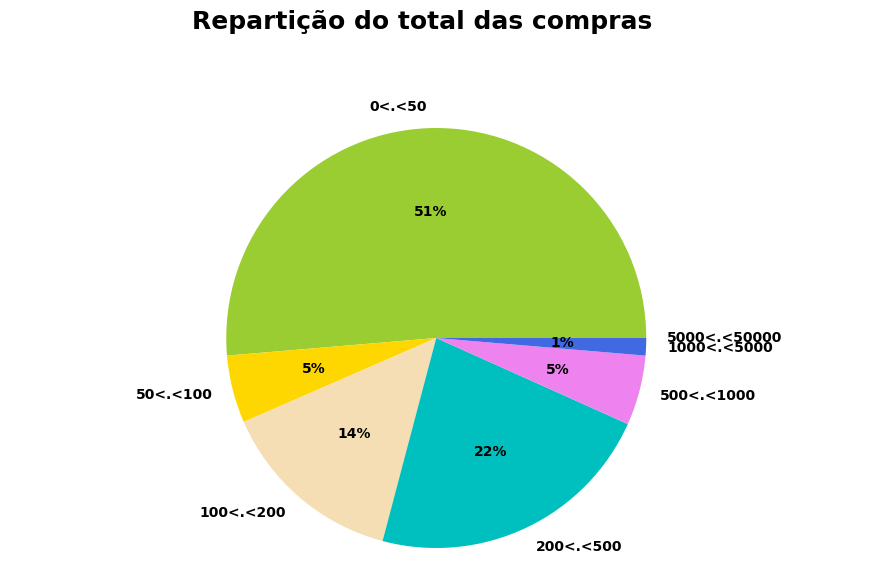

In [46]:
# Plot the distribution of the purchases

plt.rc('font', weight='bold')
f, ax = plt.subplots(figsize=(11, 6))
colors = ['yellowgreen', 'gold', 'wheat', 'c', 'violet', 'royalblue','firebrick']
labels = [ '{}<.<{}'.format(price_range[i-1], s) for i,s in enumerate(price_range) if i != 0]
sizes  = count_price
explode = [0.0 if sizes[i] < 100 else 0.0 for i in range(len(sizes))]
ax.pie(sizes, explode = explode, labels=labels, colors = colors,
       autopct = lambda x:'{:1.0f}%'.format(x) if x > 1 else '',
       shadow = False, startangle=0)
ax.axis('equal')
f.text(0.5, 1.01, "Breakdown of the purchase totals", ha='center', fontsize = 18);

- Based on the results obtained, most purchases (by order number) fall between 0 and 50, representing 51% of the total, followed by baskets with values from 200 to 500, which represent 22% of the orders.

### 1.8 Codes in stock_code

In [47]:
# Getting the special codes present in the stock_code cells
list_special_codes = ecommerce_clean_27[ecommerce_clean_27['stock_code'].str.contains('^[a-zA-Z]+', regex=True)]['stock_code'].unique()
print(list_special_codes)

['POST' 'C2' 'M' 'BANK CHARGES']


In [48]:
for code in list_special_codes:
    print("{:<15} -> {:<30}".format(code, ecommerce_clean_27[ecommerce_clean_27['stock_code'] == code]['description'].unique()[0]))

POST            -> POSTAGE                       
C2              -> CARRIAGE                      
M               -> Manual                        
BANK CHARGES    -> Bank Charges                  


- We can see that there are cases with different transactions in the dataframe

## 2 Adding data

### 2.1 Add date, year, month and day columns to the dataframe based on invoice_date

In [49]:
ecommerce_clean_27['date'] = ecommerce_clean_27['invoice_date'].dt.date

C:\Users\renan\AppData\Local\Temp\ipykernel_4032\1964287090.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ecommerce_clean_27['date'] = ecommerce_clean_27['invoice_date'].dt.date


In [50]:
# Getting the results after adding the 'date' column
print(ecommerce_clean_27.head())

  invoice_no stock_code                     description  quantity  \
2     537626     85232D   SET/3 DECOUPAGE STACKING TINS         3   
3     537626      22725  ALARM CLOCK BAKELIKE CHOCOLATE         4   
4     537626      22726      ALARM CLOCK BAKELIKE GREEN         4   
5     537626      22727       ALARM CLOCK BAKELIKE RED          4   
6     537626      22728       ALARM CLOCK BAKELIKE PINK         4   

         invoice_date  unit_price  customer_id  total_spent        date  
2 2018-12-05 14:57:00        4.95        12347        14.85  2018-12-05  
3 2018-12-05 14:57:00        3.75        12347        15.00  2018-12-05  
4 2018-12-05 14:57:00        3.75        12347        15.00  2018-12-05  
5 2018-12-05 14:57:00        3.75        12347        15.00  2018-12-05  
6 2018-12-05 14:57:00        3.75        12347        15.00  2018-12-05  


In [51]:
ecommerce_clean_27.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36844 entries, 2 to 41230
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   invoice_no    36844 non-null  object        
 1   stock_code    36844 non-null  object        
 2   description   36844 non-null  object        
 3   quantity      36844 non-null  int64         
 4   invoice_date  36844 non-null  datetime64[ns]
 5   unit_price    36844 non-null  float64       
 6   customer_id   36844 non-null  int32         
 7   total_spent   36844 non-null  float64       
 8   date          36844 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 2.7+ MB


- Adding the new columns to the Dataframe worked

## 3 Cohort Analysis

#### 3.1 Revenue per user

In [52]:
#Copy the formatted data to another dataframe to work with
coorte_data = ecommerce_clean_27.copy()

In [53]:
# Grouping the data by customer and purchase date and taking the minimum value
first_order_date_by_customers = coorte_data.groupby('customer_id')['invoice_date'].min()

In [54]:
# Renaming the column
first_order_date_by_customers.name = 'first_order_date'

In [55]:
# Joining the minimum date data for each user
coorte_data = coorte_data.join(first_order_date_by_customers, on='customer_id')

In [56]:
#Extracting the month of the first order
coorte_data['first_order_month'] = pd.to_datetime(coorte_data['first_order_date'], format='%Y-%m-%d').dt.to_period('M')

In [57]:
#extracting the month of the order
coorte_data['order_month'] = pd.to_datetime(coorte_data['invoice_date'], format='%Y-%m-%d').dt.to_period('M')

In [58]:
#Group the total spent and unique users by the first order month and the order month
orders_grouped_by_cohorts = coorte_data.groupby(['first_order_month', 'order_month']).agg({'total_spent': 'sum', 'customer_id': 'nunique'})

In [59]:
#Calculate the revenue per user
orders_grouped_by_cohorts['revenue_per_user'] = (orders_grouped_by_cohorts['total_spent']/ orders_grouped_by_cohorts['customer_id'])

In [60]:
#Create the pivot table based on the periods of each cohort
value_spent = orders_grouped_by_cohorts.pivot_table(
    index='first_order_month',
    columns='order_month',
    values='revenue_per_user',
    aggfunc='mean',
)

print(value_spent)

order_month           2018-11     2018-12     2019-01    2019-02    2019-03  \
first_order_month                                                             
2018-11            300.513621  577.375937  437.268333  15.708571  16.772353   
2018-12                   NaN  395.600940  383.925301  18.461818  17.804130   
2019-01                   NaN         NaN  293.429120  23.503333  13.381818   
2019-02                   NaN         NaN         NaN  20.600000  24.000000   
2019-03                   NaN         NaN         NaN        NaN  15.144205   
2019-04                   NaN         NaN         NaN        NaN        NaN   
2019-05                   NaN         NaN         NaN        NaN        NaN   
2019-06                   NaN         NaN         NaN        NaN        NaN   
2019-07                   NaN         NaN         NaN        NaN        NaN   
2019-08                   NaN         NaN         NaN        NaN        NaN   
2019-09                   NaN         NaN         Na

Text(0.5, 69.7222222222222, 'Mês da compra')

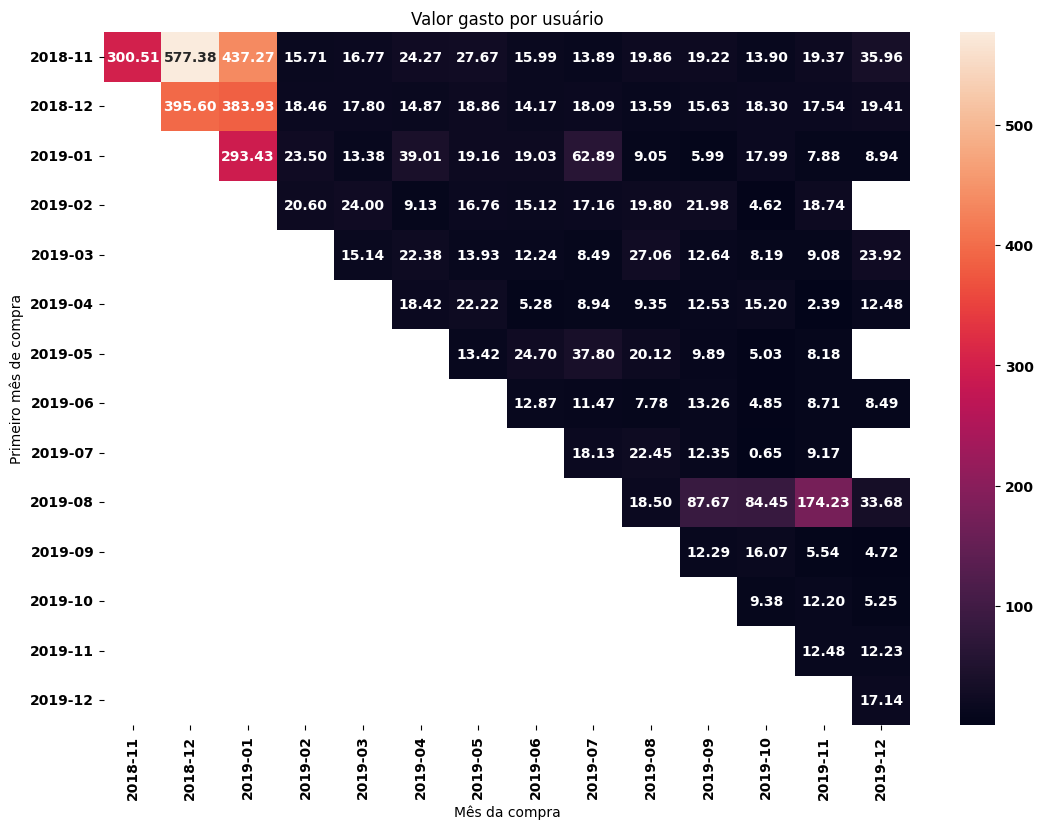

In [61]:
# Plotting a heatmap

plt.figure(figsize=(13,9))
plt.title('Amount spent per user')
sns.heatmap(value_spent,
            annot=True,
            fmt='.2f',
            linecolor='black',)
plt.ylabel("First purchase month")
plt.xlabel("Purchase month")

- Conclusion
    - Based on the data obtained we can see that for most cohorts there is a reduction in spending per user over time.

## 4 Segmentation

### 4.1 RFM (recency, frequency, monetary)

In [62]:
rfm_dataframe = ecommerce_clean_27.copy()

In [63]:
rfm_dataframe.describe()

,quantity,invoice_date,unit_price,customer_id,total_spent
count,36844.000000,36844,36844.000000,36844.000000,36844.000000
mean,6.917490,2018-12-31 10:57:37.347736064,3.171272,15405.471909,14.526461
min,1.000000,2018-11-29 08:26:00,0.000000,12347.000000,0.000000
25%,2.000000,2018-12-05 11:59:00,1.250000,14032.000000,4.200000
50%,4.000000,2018-12-12 14:42:00,2.100000,15384.000000,10.200000
75%,12.000000,2019-01-05 16:32:00,3.750000,17019.000000,17.700000
max,27.000000,2019-12-07 12:16:00,295.000000,18283.000000,559.200000
std,6.762105,NaN,5.388481,1763.404482,19.117818


In [64]:
# Getting the earliest and latest date values of the data range

menor_data, maior_data = rfm_dataframe['invoice_date'].min(), rfm_dataframe['invoice_date'].max()
maior_data = maior_data + pd.DateOffset(days=1) #One day added to the latest purchase to start the analysis

In [65]:
# Getting the ten largest sales
rfm_dataframe.groupby('invoice_date')[['total_spent']].sum().sort_values('total_spent', ascending=False)[:10]

,total_spent
invoice_date,
2019-01-04 16:41:00,3164.10
2019-01-05 12:28:00,2140.11
2018-12-08 15:45:00,1904.88
2018-12-12 12:59:00,1883.12
2018-12-06 15:56:00,1826.51
2018-12-07 12:17:00,1764.15
2019-01-08 09:11:00,1715.85
2018-12-11 15:44:00,1669.52
2018-12-01 14:04:00,1648.29


In [66]:
# Find out which products sell the most

print('Best-selling products (quantity)', '\n', 60 *'-')
print(rfm_dataframe.groupby('description')[['quantity','total_spent']].sum().sort_values('quantity',ascending=False)[:10])
print()
print(60 * '*')
print('Best-selling products (value)', '\n', 60 *'-')
print(rfm_dataframe.groupby('description')[['quantity','total_spent']].sum().sort_values('total_spent',ascending=False)[:10])

Produtos mais vendidos (quantidade) 
 ------------------------------------------------------------
                                    quantity  total_spent
description                                              
FANCY FONT BIRTHDAY CARD                3240      1360.80
FEATHER PEN HOT PINK                    2054      1027.32
KEY FOB SHED                            1977      1316.41
ELEPHANT BIRTHDAY CARD                  1562       656.04
WHITE HANGING HEART T-LIGHT HOLDER      1559      4555.05
KEY FOB BACK DOOR                       1550      1021.22
JAM MAKING SET PRINTED                  1524      2209.80
BIRTHDAY CARD RETRO SPOT                1452       609.84
FEATHER PEN COAL BLACK                  1406       735.30
HAND WARMER BABUSHKA DESIGN             1398      2095.80

************************************************************
Produtos mais vendidos (valor) 
 ------------------------------------------------------------
                                    quantity  tot

- We now have the top 10 best-selling products by quantity and the top 10 best-selling products by revenue generated

In [67]:
# Split the values into four analysis periods

periodoA, periodoB, periodoC, periodoD = pd.date_range(menor_data, maior_data, periods=4)

In [68]:
rfm_table = rfm_dataframe.groupby('customer_id').agg({'invoice_date': lambda date: (maior_data - date.max()).days,
                                                      'invoice_no': lambda num: len(num),
                                                      'total_spent': lambda valor: valor.sum()})

# Rename the columns to match the RFM analysis
rfm_table.columns = ['recency','frequency','monetary']
display(rfm_table.head(10).sort_values('monetary', ascending=False))


,recency,frequency,monetary
customer_id,,,
12356,326,22,1565.58
12370,51,87,1550.77
12377,355,43,1001.52
12347,183,30,661.09
12359,331,16,547.50
12348,358,5,292.80
12357,33,5,106.56
12378,130,1,51.00
12360,113,1,5.04


- This table shows us that the consumer who spent the most brought in 1565.58, with a low frequency compared to the previous one, but it has been a while since they made a purchase, since the recency is 326 days.

In [69]:
# Rename the columns to match the RFM analysis
rfm_table.columns = ['recency','frequency','monetary']

# View the result
display(rfm_table.head(10).sort_values('frequency', ascending=False))

,recency,frequency,monetary
customer_id,,,
12370,51,87,1550.77
12377,355,43,1001.52
12347,183,30,661.09
12356,326,22,1565.58
12359,331,16,547.50
12348,358,5,292.80
12357,33,5,106.56
12360,113,1,5.04
12364,40,1,5.04


- This table shows us that some customers have a higher purchase frequency on the site.

In [70]:
# Sort by 'recency'

rfm_table.columns = ['recency','frequency','monetary']
# View the result
display(rfm_table.head(10).sort_values('recency', ascending=False))

,recency,frequency,monetary
customer_id,,,
12348,358,5,292.80
12377,355,43,1001.52
12359,331,16,547.50
12356,326,22,1565.58
12347,183,30,661.09
12378,130,1,51.00
12360,113,1,5.04
12370,51,87,1550.77
12364,40,1,5.04


- This table shows us that we have some consumers who have not made a purchase in more than 300 days.

In [71]:
# Classifying the data according to quartiles 
rfm_table['recency_quartile'] = pd.qcut(rfm_table['recency'], 4, ['1','2','3','4']) # more recent, more important
rfm_table['frequency_quartile'] = pd.qcut(rfm_table['frequency'], 4, ['4','3','2','1']) # less frequency, less important
rfm_table['monetary_quartile'] = pd.qcut(rfm_table['monetary'], 4, ['4','3','2','1']) # less spending, less important

In [72]:
# Displaying the result
print(rfm_table.head())

             recency  frequency  monetary recency_quartile frequency_quartile  \
customer_id                                                                     
12347            183         30    661.09                2                  1   
12348            358          5    292.80                4                  3   
12356            326         22   1565.58                3                  2   
12357             33          5    106.56                1                  3   
12359            331         16    547.50                3                  2   

            monetary_quartile  
customer_id                    
12347                       1  
12348                       2  
12356                       1  
12357                       3  
12359                       1  


In [73]:
# Getting each user's score based on recency and frequency
rfm_table['rfm_score'] = rfm_table.recency_quartile.astype(str) + rfm_table.frequency_quartile.astype(str)
rfm_table.head().sort_values('rfm_score', ascending=False)

,recency,frequency,monetary,recency_quartile,frequency_quartile,monetary_quartile,rfm_score
customer_id,,,,,,,
12348,358,5,292.80,4,3,2,43
12356,326,22,1565.58,3,2,1,32
12359,331,16,547.50,3,2,1,32
12347,183,30,661.09,2,1,1,21
12357,33,5,106.56,1,3,3,13


- With the help of the score we can identify which customers have a higher RFM rating and possibly send them promotions.
    - This strategy also applies to customers with a low rating: what can be sent to them to encourage them to buy on the site?

- Furthermore, based on the rfm_score it is then possible to segment the customers into groups: high, medium and low.

In [74]:
# Create the customer segmentation
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_risk',
    r'[1-2]5': 'cant_lose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

rfm_table['segment'] = rfm_table['rfm_score'].astype(str).replace(seg_map, regex=True)

print(rfm_table.head().sort_values('rfm_score', ascending=False))


             recency  frequency  monetary recency_quartile frequency_quartile  \
customer_id                                                                     
12348            358          5    292.80                4                  3   
12356            326         22   1565.58                3                  2   
12359            331         16    547.50                3                  2   
12347            183         30    661.09                2                  1   
12357             33          5    106.56                1                  3   

            monetary_quartile rfm_score              segment  
customer_id                                                   
12348                       2        43  potential_loyalists  
12356                       1        32       about_to_sleep  
12359                       1        32       about_to_sleep  
12347                       1        21          hibernating  
12357                       3        13              a

In [75]:
'''
Champions — bought recently, buy often and spend the most.
Loyal Customers — spend good money and respond well to promotions.
Potential Loyalists — recent customers who spent a good amount and bought more than once.
New Customers — bought recently, but not often.
Promissing — recent buyers, but who have not spent much.
Need Attention — above-average recency, frequency and monetary values; but they may not have bought very recently.
About To Sleep — below-average recency, frequency and monetary values; they will be lost if they are not reactivated.
At Risk — spent a lot of money and bought often, but a long time ago; they need to be brought back.
Can't Lose Them — made large and frequent purchases, but have not transacted again in a long time.
Hibernating — their last purchase was a long time ago, low spenders and a low number of orders.'''

'\nChampions — compraram recentemente, compram com frequência e gastam mais.\nLoyal Customers — gastam um bom dinheiro e respondem bem às promoções.\nPotential Loyalists — clientes recentes, que gastaram uma boa quantia e compraram mais de uma vez.\nNew Customers — compraram recentemente, mas não com frequência.\nPromissing — compradores recentes, mas que não gastaram muito.\nNeed Attention — recência, frequência e valores monetários acima da média; mas podem não ter comprado muito recentemente.\nAbout To Sleep — recência, frequência e valores monetários abaixo da média; serão perdidos se não forem reativados.\nAt Risk — gastaram muito dinheiro e compraram com frequência, mas há muito tempo; é preciso trazê-los de volta.\nCan’t Lose Them — fizeram compras grandes e muitas vezes, mas não voltam a realizar transações há muito tempo.\nHibernating — a última compra foi há muito tempo, pouco gastadores e baixo número de pedidos.'

In [76]:
print(rfm_table.columns)

Index(['recency', 'frequency', 'monetary', 'recency_quartile',
       'frequency_quartile', 'monetary_quartile', 'rfm_score', 'segment'],
      dtype='object')


Text(0.5, 1.0, 'Número total de usuários por segmento')

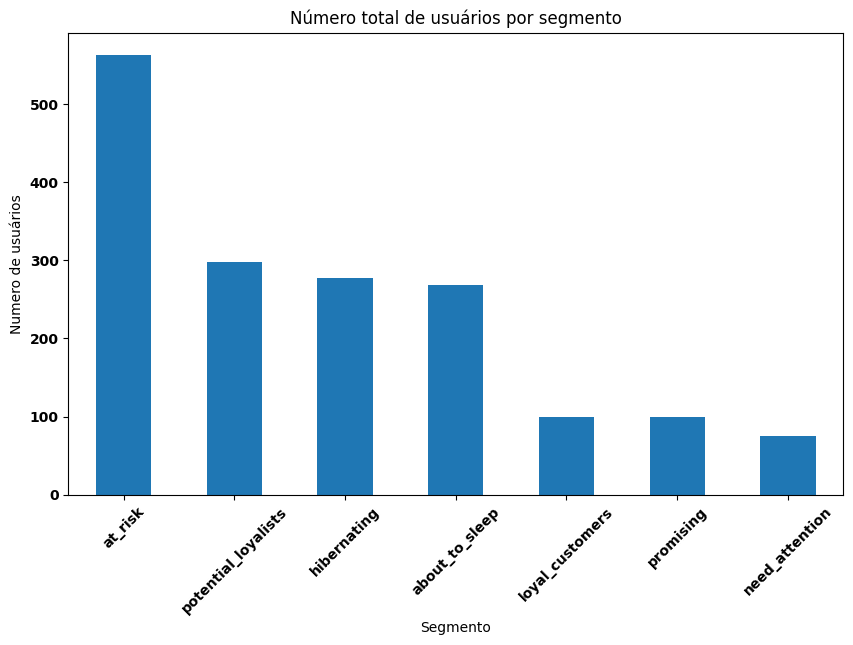

In [77]:
# Create a bar chart for the distribution of the total number of users within each segment

segment_users = rfm_table['segment'].value_counts()

# Plotting the data
plt.figure(figsize=[10,6])
segment_users.plot(kind='bar')
plt.ylabel('Number of users')
plt.xlabel('Segment')
plt.xticks(rotation=45)
plt.title("Total number of users per segment")

In [78]:
print(segment_users)

segment
at_risk                563
potential_loyalists    298
hibernating            277
about_to_sleep         268
loyal_customers        100
promising               99
need_attention          75
Name: count, dtype: int64


- Conclusion 
    - Based on the bar chart we can see that most customers fall into the at-risk segment (at_risk). Potential loyal customers (potential_loyalists) come second, and customers in a hibernating state (hibernating) and about to hibernate (about_to_sleep) are also among the most representative customers.
   

### 4.2 By products

#### 4.2.1 Extract the keywords from the product descriptions.

In [79]:
# Copy the transformed data to use in the segmentation by products

per_product_df = ecommerce_clean_27.copy()

- The segmentation can be done by product name for later grouping of the data

In [80]:
# Extract the variable from the description

is_noun = lambda pos: pos[:2] == 'NN'

# Creating the function

def keywords_inventory(dataframe, colonne = 'description'):
    stemmer = nltk.stem.SnowballStemmer("english") # understands that the words are in English
    keywords_roots = dict() #collects the words
    keywords_select = dict() #associates the root with the word
    category_keys = []
    count_keywords = dict()
    icount = 0
    for s in dataframe[colonne]:
        if pd.isnull(s): continue
        lines = s.lower()
        tokenized = nltk.word_tokenize(lines)
        nouns = [word for (word,pos) in nltk.pos_tag(tokenized) if is_noun(pos)]

        for t in nouns:
            t = t.lower() ; racine = stemmer.stem(t)
            if racine in keywords_roots:
                keywords_roots[racine].add(t)
                count_keywords[racine] += 1
            else:
                keywords_roots[racine] = {t}
                count_keywords[racine] = 1
    
    for s in keywords_roots.keys():
        if len(keywords_roots[s])> 1:
            min_length = 1000
            for k in keywords_roots[s]:
                if len(k) < min_length:
                    clef = k ; min_length = len(k)
            category_keys.append(clef)
            keywords_select[s] = clef
        else:
            category_keys.append(list(keywords_roots[s])[0])
            keywords_select[s] = list(keywords_roots[s])[0]
    
    print("Num of keywords in variable '{}' : {}".format(colonne,len(category_keys)))
    return category_keys,keywords_roots, keywords_select, count_keywords


- In summary, this function:
    - Extracts the nouns that appear in the product descriptions
    - For each noun, extracts the root of the word and aggregates the set of nouns associated with that particular word
    - counts the number of times each 'root' appears in the dataframe
    - when several words are listed for the same root, considers the word associated with that root to be the shortest noun

In [81]:
# Return the list of products

df_products = pd.DataFrame(per_product_df['description'].unique()).rename(columns={0:'description'})

In [82]:
# After creating the list, I use the function to analyze the description of the various products
keywords, keywords_roots, keywords_select, count_keywords = keywords_inventory(df_products)

Num de palavras chave na variavel 'description' : 1176


In [83]:
'''
This results in three variables:
    keywords: the list of extracted keywords
    keywords_roots: a dictionary where the keys are the keywords and the values are the list of words associated with those roots
    count_keywords: a dictionary listing the number of times each word is used
'''

'\nIsso resulta em três variáveis:\n    keywords: a lista das palavras chave extraidas\n    keywords_roots: um dicionário onde as chaves são as palavras chaves e os valores a lista de palavras associadas a essas raizes\n    count_keywords: um dicionario listando o número de vezes que cada palavra é usada\n'

In [84]:
# Turn count_keywords into a list in order to distribute them according to frequency

list_products = []
for k, v in count_keywords.items():
    list_products.append([keywords_select[k],v])
list_products.sort(key = lambda x:x[1], reverse = True)

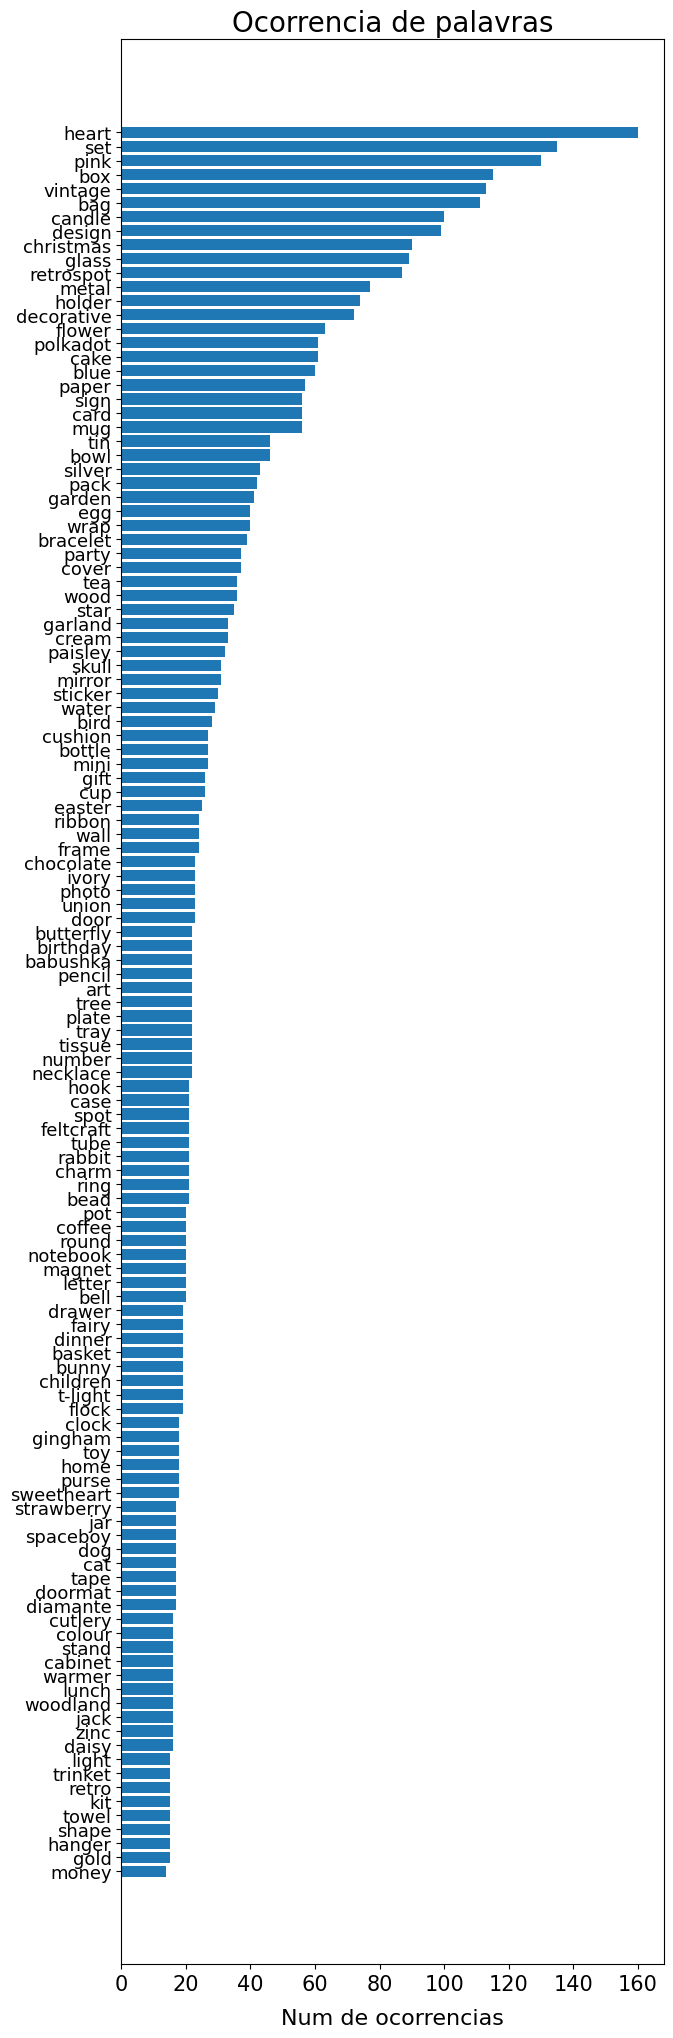

In [85]:
# Plot the result

list = sorted(list_products, key = lambda x:x[1], reverse = True)

plt.rc('font', weight='normal')
fig, ax = plt.subplots(figsize=(7, 25))
y_axis = [i[1] for i in list[:125]]
x_axis = [k for k,i in enumerate(list[:125])]
x_label = [i[0] for i in list[:125]]
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 13)
plt.yticks(x_axis, x_label)
plt.xlabel("Num of occurrences", fontsize = 16, labelpad = 10)
ax.barh(x_axis, y_axis, align = 'center')
ax = plt.gca()
ax.invert_yaxis()

plt.title("Word occurrences",fontsize = 20)
plt.show()

- The separation of the results worked; I managed to extract the first word and the total number of times they appear.
- There are many results showing up. In this case there are some words that do not help with the classification (e.g. colors), so I can remove them.
- Besides that, I want to work with words that appeared more than 20 times.

#### 4.2.2 Define the product categories

In [86]:
list_products = []
for k,v in count_keywords.items():
    word = keywords_select[k]
    if word in ['pink', 'blue', 'tag', 'green', 'orange']: continue  #remove unnecessary words
    if len(word) < 3 or v < 20: continue # work with words that appeared more than 20 times
    if ('+' in word) or ('/' in word): continue
    list_products.append([word, v])
#______________________________________________________    
list_products.sort(key = lambda x:x[1], reverse = True)
print('Words kept:', len(list_products))

Palavras conservadas: 82


#### 4.2.3 Encode the data

- Based on the data obtained I need to build a matrix X that indicates the words in the products' 'description' using one-hot encoding.
- In addition, considering the purchase ranges, I can add 6 columns to the matrix indicating the price range of the products.

In [ ]:
list_of_products = per_product_df['description'].unique()
X = pd.DataFrame()
for product in list_of_products:
    X[product] = ecommerce_clean_27['description'].str.upper().str.contains(product.upper()).astype(int)

In [ ]:
# Creating the unit price ranges

threshold = [0, 1, 2, 3, 5, 10]
label_col = []
for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i],threshold[i+1])
    label_col.append(col)
    X.loc[:, col] = 0

for i, prod in enumerate(list_of_products):
    prix = per_product_df[ per_product_df['description'] == prod]['unit_price'].mean()
    j = 0
    while prix > threshold[j]:
        j+=1
        if j == len(threshold): break
    X.loc[i, label_col[j-1]] = 1

In [91]:
# Check the number of values in each unit price range

print("{:<8} {:<20} \n". format('range','num products'))

for i in range(len(threshold)):
    if i == len(threshold)-1:
        col = '.>{}'.format(threshold[i])
    else:
        col = '{}<.<{}'.format(threshold[i],threshold[i+1])
    print("{:<10}   {:<20}".format(col,X.loc[:, col].sum()))

faixa    num produtos         

0<.<1        566.0               
1<.<2        745.0               
2<.<3        509.0               
3<.<5        352.0               
5<.<10       285.0               
.>10         93.0                


- According to the distribution, we can see that most products (745) fall in the unit price range between 1 and 2.

#### 4.2.4 Create product groups

In [92]:
one = OneHotEncoder()

one.fit(X)

X = one.transform(X)

In [93]:
matrix = X.toarray()
for n_clusters in range(3,10):
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 3 The average silhouette_score is : 0.18008914701509315
For n_clusters = 4 The average silhouette_score is : 0.18627940751066457
For n_clusters = 5 The average silhouette_score is : 0.19220097153370988
For n_clusters = 6 The average silhouette_score is : 0.02713079879738164
For n_clusters = 7 The average silhouette_score is : 0.02930232479251647
For n_clusters = 8 The average silhouette_score is : 0.041225705722255125
For n_clusters = 9 The average silhouette_score is : 0.03612252306002949


- In this case the n_clusters with the best average silhouette score was 5, so I will work with that value.
    - Note: the average silhouette score ranges from -1 to 1, where values close to 1 mean that the points are close to each other, 0 that the clusters overlap and -1 that they have been grouped incorrectly.

In [95]:
# Working with n_clusters = 5
n_clusters = 5
silhouette_avg = -1
while silhouette_avg < 0.145:
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
    kmeans.fit(matrix)
    clusters = kmeans.predict(matrix)
    silhouette_avg = silhouette_score(matrix, clusters)
    
    #km = kmodes.KModes(n_clusters = n_clusters, init='Huang', n_init=2, verbose=0)
    #clusters = km.fit_predict(matrix)
    #silhouette_avg = silhouette_score(matrix, clusters)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 5 The average silhouette_score is : 0.01793508370820823
For n_clusters = 5 The average silhouette_score is : 0.18802423732618043


#### 4.2.5 Characterizing the content of the groups

In [96]:
pd.Series(clusters).value_counts()

0    35635
4      649
2      319
1      305
3      241
Name: count, dtype: int64

- We can see that among the 5 groups, group zero is the one with the largest number of products.

### 4.2.6 Product categories

- Based on the previous clustering and the creation of the five groups, I now need to assign the cluster number to each product.

In [115]:
# Assigning the group values to each product
corresp = dict()
for key, val in zip (list_of_products, clusters):
    corresp[key] = val 
#__________________________________________________________________________
per_product_df['categ_product'] = per_product_df.loc[:, 'description'].map(corresp)

Next I can create columns stating what the total spent in each product category was.

In [118]:
for i in range(5):
    col = 'categ_{}'.format(i)        
    df_temp = per_product_df[per_product_df['categ_product'] == i]
    price_temp = df_temp['unit_price'] * (df_temp['quantity'])
    price_temp = price_temp.apply(lambda x:x if x > 0 else 0)
    per_product_df.loc[:, col] = price_temp
    per_product_df[col].fillna(0, inplace = True)
#__________________________________________________________________________________________________
display(per_product_df[['invoice_no', 'description', 'categ_product', 'categ_0', 'categ_1', 'categ_2', 'categ_3','categ_4']][:5])

,invoice_no,description,categ_product,categ_0,categ_1,categ_2,categ_3,categ_4
2,537626,SET/3 DECOUPAGE STACKING TINS,2,0.0,0.0,14.85,0.0,0.0
3,537626,ALARM CLOCK BAKELIKE CHOCOLATE,2,0.0,0.0,15.00,0.0,0.0
4,537626,ALARM CLOCK BAKELIKE GREEN,2,0.0,0.0,15.00,0.0,0.0
5,537626,ALARM CLOCK BAKELIKE RED,2,0.0,0.0,15.00,0.0,0.0
6,537626,ALARM CLOCK BAKELIKE PINK,2,0.0,0.0,15.00,0.0,0.0


- With this I have, broken down by category, what the total spent on a given product was.
- I can separate it by creating a dataframe to group by order

In [147]:
count_categ_prod = per_product_df['categ_product'].value_counts()
print(count_categ_prod)

categ_product
0    20147
4    11024
2     5491
3      182
Name: count, dtype: int64


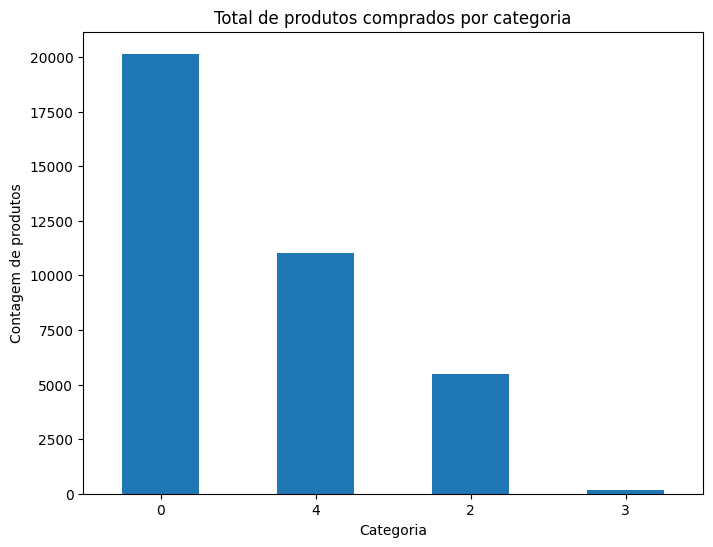

In [151]:
# Plotting the product count per category

plt.figure(figsize=[8,6])
count_categ_prod.plot(kind='bar')
plt.ylabel('Product count')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.title('Total products purchased per category')
plt.show()

- The data shows us that category zero is the one with the most products sold (20147).

In [119]:
# Create a temporary table with the aggregated values
temp = per_product_df.groupby(by=['customer_id', 'invoice_no'], as_index=False)['total_spent'].sum()
basket_price = temp.rename(columns = {'total_spent':'basket_price'})

In [125]:
# Create the for loop to iterate over each of the values 
for i in range(5):
    col = 'categ_{}'.format(i) 
    temp = per_product_df.groupby(by=['customer_id', 'invoice_no'], as_index=False)[col].sum()
    basket_price[col] = temp[col]

In [126]:
# Creating a temporary column in the dataframe to group by amount spent per category
per_product_df['InvoiceDate_int'] = per_product_df['invoice_date'].astype('int64')
temp = per_product_df.groupby(by=['customer_id', 'invoice_no'], as_index=False)['InvoiceDate_int'].mean()
per_product_df.drop('InvoiceDate_int', axis = 1, inplace = True)
basket_price.loc[:, 'invoice_date'] = pd.to_datetime(temp['InvoiceDate_int'])

In [127]:
# Printing the results
basket_price = basket_price[basket_price['basket_price'] > 0]
basket_price.sort_values('customer_id', ascending = True)[:5]

,customer_id,invoice_no,basket_price,categ_0,invoice_date,categ_1,categ_2,categ_3,categ_4
0,12347,537626,650.89,255.8,2018-12-05 14:57:00,0.0,184.25,0.0,210.84
1,12347,556201,10.20,10.2,2019-06-07 13:01:00,0.0,0.00,0.0,0.00
2,12348,539318,292.80,279.6,2018-12-14 19:09:00,0.0,0.00,0.0,13.20
3,12356,541430,1565.58,815.7,2019-01-16 09:50:00,0.0,346.20,0.0,403.68
4,12357,574740,106.56,63.0,2019-11-04 16:07:00,0.0,20.16,0.0,23.40


- In this case we can then see the user id, the total of the order they placed and the total per product category previously defined.

Next I can aggregate the count of purchases made by the user as well as the minimum, average, maximum and total amounts spent across all visits.

In [129]:
# Calculate the minimum, maximum, average and total values of the purchases made by the consumers and append them to the dataframe
transactions_per_user=basket_price.groupby(by=['customer_id'])['basket_price'].agg(['count','min','max','mean','sum'])
for i in range(5):
    col = 'categ_{}'.format(i)
    transactions_per_user.loc[:,col] = basket_price.groupby(by=['customer_id'])[col].sum() /\
                                            transactions_per_user['sum']*100

transactions_per_user.reset_index(drop = False, inplace = True)
basket_price.groupby(by=['customer_id'])['categ_0'].sum()
display(transactions_per_user.sort_values('customer_id', ascending = True)[:5])

,customer_id,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4
0,12347,2,10.20,650.89,330.545,661.09,40.236579,0.0,27.870638,0.000000,31.892783
1,12348,1,292.80,292.80,292.800,292.80,95.491803,0.0,0.000000,0.000000,4.508197
2,12356,1,1565.58,1565.58,1565.580,1565.58,52.102096,0.0,22.113210,0.000000,25.784693
3,12357,1,106.56,106.56,106.560,106.56,59.121622,0.0,18.918919,0.000000,21.959459
4,12359,1,547.50,547.50,547.500,547.50,29.369863,0.0,56.812785,2.712329,11.105023


- The aggregation of the new values worked.

Finally I can add the number of days since the first purchase and the number of days since the last purchase

In [ ]:
# Getting the last recorded day
last_date = basket_price['invoice_date'].max().date()

# Getting the registration and last purchase dates
first_registration = pd.DataFrame(basket_price.groupby(by=['customer_id'])['invoice_date'].min())
last_purchase      = pd.DataFrame(basket_price.groupby(by=['customer_id'])['invoice_date'].max())

test  = first_registration.applymap(lambda x:(last_date - x.date()).days)
test2 = last_purchase.applymap(lambda x:(last_date - x.date()).days)

# Adding the data to the dataframe
transactions_per_user.loc[:, 'LastPurchase'] = test2.reset_index(drop = False)['invoice_date']
transactions_per_user.loc[:, 'FirstPurchase'] = test.reset_index(drop = False)['invoice_date']

display(transactions_per_user[:5])

In [135]:
transactions_per_user.describe()

,customer_id,count,min,max,mean,sum,categ_0,categ_1,categ_2,categ_3,categ_4,LastPurchase,FirstPurchase
count,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000,1680.0,1680.000000,1680.000000,1680.000000,1680.000000,1680.000000
mean,15343.654762,2.046429,115.384881,217.528095,158.550471,318.579131,53.765879,0.0,15.819367,0.470416,29.944339,229.729167,285.975595
std,1726.899164,3.030162,192.682993,276.771830,201.786875,544.907179,31.956771,0.0,23.965802,3.323302,28.424161,132.743883,113.517794
min,12347.000000,1.000000,0.190000,0.190000,0.190000,0.190000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13870.750000,1.000000,5.040000,15.600000,14.040000,19.725000,36.690328,0.0,0.000000,0.000000,5.486544,99.750000,233.000000
50%,15368.000000,1.000000,19.800000,147.125000,104.212500,164.175000,56.793059,0.0,8.849954,0.000000,25.485130,277.000000,351.000000
75%,16873.500000,2.000000,166.605000,309.497500,234.821250,380.402500,73.674604,0.0,18.870006,0.000000,40.271817,357.000000,366.000000
max,18283.000000,57.000000,2140.110000,3164.100000,2140.110000,8185.390000,100.000000,0.0,100.000000,100.000000,100.000000,373.000000,373.000000


- Conclusion
    - It was possible to distribute the products into 5 categories where, on average, customers spend the most on category 0 (53.76), followed by products belonging to category 4 (29.94)
    - On the overall average, consumers spend 158.55 on products, where the average minimum value is 115.38 and the maximum is 217.52 per basket.
    - In the category split, no product fell into category 1.

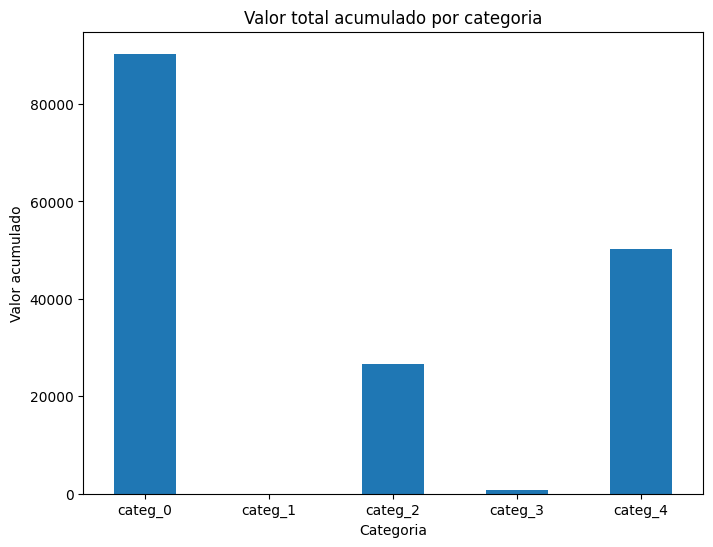

In [144]:
total_per_category = transactions_per_user[['categ_0', 'categ_1', 'categ_2', 'categ_3','categ_4']].sum()

plt.figure(figsize=[8,6])
total_per_category.plot(kind='bar')
plt.ylabel('Cumulative value')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.title('Total cumulative value per category')
plt.show()

In [145]:
print(total_per_category)

categ_0    90326.676115
categ_1        0.000000
categ_2    26576.536764
categ_3      790.298422
categ_4    50306.488699
dtype: float64


- The chart shows us that the products belonging to category 0 were the ones that generated the most financial return for the company.

## 5 Conclusion

Cohort analysis:
- The cohort analysis of spending per user shows that in most cases there is higher spending at the beginning, which tends to decrease over time and then settles into a steady range of values.
    - Action point: study the marketing strategies used over time, aiming for greater interaction with the customer so that they keep buying.

Based on the RFM analysis:
- It is important to take some action in order not to lose customers who are hibernating or about to hibernate.
    - Some marketing activity is needed (sending a promotion, reaching out to these customers) to encourage them to buy again.
    - Another option would be to conduct market research (perhaps a satisfaction survey) to understand what is happening, since we have many customers at risk and in a hibernating or about-to-hibernate state.

Based on the grouping by product:
- Products in category zero are the ones that brought the company the most return, and they are also the best-selling products.
    - Action point: it is worth keeping these products in the lineup, as they are the ones that bring the company the most return.
- Products in category 3 brought the company the least revenue (790.00), and they were also the least sold products (182 records).
    - Action point: it is necessary to study the feasibility of keeping these products in stock; it may be worth clearing out whatever remains in inventory and cancelling new orders.

### Create csv files to use in Tableau

To build the dashboards in Tableau I will use the already formatted DataFrames.

In [152]:
# The dataframe with the transformed data
ecommerce_clean_27.to_csv('ecommerce_tableau.csv')

# The dataframe with the data obtained from RFM
rfm_table.to_csv('rfm_data.csv')

# The dataframe containing the product names and the categories they fall into
per_product_df.to_csv('categ_per_prod.csv')

# The dataframe showing the amount spent per category and user
transactions_per_user.to_csv('transac_per_user.csv')

- The export worked.  